## Gradient descent
Gradient descent is an iterative first-order optimization method that finds (local) minima of a differentiable function by moving parameters in the direction of steepest descent given by the negative gradient. It is the foundational algorithm used to train many machine‑learning models because it uses gradient information to reduce a loss function step by step.

---

### Basic math and update rule
- Let the objective (loss) be a differentiable function $L(\theta)$ where $\theta \in \mathbb{R}^n$ are the parameters.  
- The gradient is $\nabla L(\theta) = \left(\frac{\partial L}{\partial \theta_1}, \dots, \frac{\partial L}{\partial \theta_n}\right)$.  
- The gradient descent update after step $t$ with step size (learning rate) $\alpha>0$ is:
$$
\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla L\big(\theta^{(t)}\big).
$$
- Intuition: the gradient points toward the direction of fastest increase; subtracting it moves parameters toward decreasing the loss.

---

### Convergence intuition and role of learning rate
- If $L$ is convex and has Lipschitz-continuous gradient, gradient descent converges to the global minimum for suitable $\alpha$; for nonconvex losses it converges to a local minimum or saddle point in practice.
- **Learning rate $\alpha$**: too large $\rightarrow$ overshoot or divergence; too small $\rightarrow$ extremely slow convergence. Typical remedies: learning‑rate schedules (decay), adaptive rates, or line search to pick $\alpha$ per step.
- For a quadratic objective $L(\theta)=\frac{1}{2}\theta^\top A\theta - b^\top\theta$ with symmetric positive definite $A$, the optimal fixed $\alpha$ lies in $(0, 2/\lambda_{\max}(A))$ where $\lambda_{\max}$ is the largest eigenvalue; this explains sensitivity to curvature differences across directions.

---

### Common practical variants
1. Batch gradient descent  
   - Uses the full dataset to compute $\nabla L$ each step; stable but expensive for large datasets.
2. Stochastic gradient descent (SGD)  
   - Uses a single example (or one minibatch element) to approximate gradient; noisy updates that can escape shallow local minima and converge faster per wall‑clock time.
3. Mini‑batch gradient descent  
   - Uses a small subset (minibatch) each update; tradeoff between stability and compute efficiency and the most common in deep learning.
4. Momentum  
   - Accumulates an exponential moving average of past gradients $v^{(t)}=\beta v^{(t-1)} + (1-\beta)\nabla L(\theta^{(t)})$ and updates $\theta^{(t+1)}=\theta^{(t)}-\alpha v^{(t)}$. Helps accelerate in low‑curvature directions and damp oscillations.
5. Adaptive methods (AdaGrad, RMSprop, Adam)  
   - Scale learning rates per parameter using past gradient magnitudes; Adam combines momentum and adaptive scaling and is widely used for deep nets.

=== Analytic gradient (1D quadratic) ===
Step   1: x = 0.0 | f(x) = 5 | ||grad|| = 4
Step   2: x = 0.8 | f(x) = 2.44 | ||grad|| = 2.4
Step   3: x = 1.28 | f(x) = 1.5184 | ||grad|| = 1.44
Step   4: x = 1.568 | f(x) = 1.18662 | ||grad|| = 0.864
Step   5: x = 1.7408000000000001 | f(x) = 1.06718 | ||grad|| = 0.5184
Step   6: x = 1.8444800000000001 | f(x) = 1.02419 | ||grad|| = 0.31104
Step   7: x = 1.9066880000000002 | f(x) = 1.00871 | ||grad|| = 0.186624
Step   8: x = 1.9440128 | f(x) = 1.00313 | ||grad|| = 0.111974
Step   9: x = 1.96640768 | f(x) = 1.00113 | ||grad|| = 0.0671846
Step  10: x = 1.979844608 | f(x) = 1.00041 | ||grad|| = 0.0403108
Step  11: x = 1.9879067648 | f(x) = 1.00015 | ||grad|| = 0.0241865
Step  12: x = 1.99274405888 | f(x) = 1.00005 | ||grad|| = 0.0145119
Step  13: x = 1.9956464353280001 | f(x) = 1.00002 | ||grad|| = 0.00870713
Step  14: x = 1.9973878611968001 | f(x) = 1.00001 | ||grad|| = 0.00522428
Step  15: x = 1.99843271671808 | f(x) = 1 | ||grad|| = 0.00313457
S

/tmp/ipykernel_61396/2019431700.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fval = float(f(x))
/tmp/ipykernel_61396/2019431700.py:83: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return x_out, float(f(x)), history


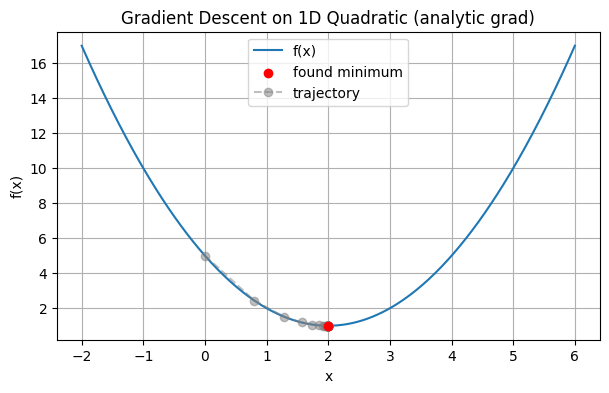

=== Numerical gradient (2D Rosenbrock) ===
Step   1: x = [-1.2  1. ] | f(x) = 24.2 | ||grad|| = 232.868
Step   2: x = [-0.9844  1.088 ] | f(x) = 5.35291 | ||grad|| = 49.0306
Step   3: x = [-1.02727157  1.06420867] | f(x) = 4.11779 | ||grad|| = 1.82616
Step   4: x = [-1.02688307  1.06242431] | f(x) = 4.11455 | ||grad|| = 1.77474
Step   5: x = [-1.02608882  1.06083722] | f(x) = 4.1114 | ||grad|| = 1.77505
Step   6: x = [-1.02531149  1.05924143] | f(x) = 4.10825 | ||grad|| = 1.77545
Step   7: x = [-1.02453275  1.05764587] | f(x) = 4.1051 | ||grad|| = 1.77586
Step   8: x = [-1.02375339  1.05605017] | f(x) = 4.10194 | ||grad|| = 1.77627
Step   9: x = [-1.02297336  1.05445433] | f(x) = 4.09879 | ||grad|| = 1.77668
Step  10: x = [-1.02219268  1.05285837] | f(x) = 4.09563 | ||grad|| = 1.77708
Step  11: x = [-1.02141133  1.05126227] | f(x) = 4.09247 | ||grad|| = 1.77749
Step  12: x = [-1.02062933  1.04966604] | f(x) = 4.08931 | ||grad|| = 1.7779
Step  13: x = [-1.01984666  1.04806968] | f(x) = 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_gradient(f, x, eps=1e-6):
    """
    Central-difference numerical gradient for vector x.
    Returns an array of same shape as x.
    """
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x, dtype=float)
    for i in range(x.size):
        orig = x.flat[i]
        x.flat[i] = orig + eps
        f_plus = f(x)
        x.flat[i] = orig - eps
        f_minus = f(x)
        grad.flat[i] = (f_plus - f_minus) / (2 * eps)
        x.flat[i] = orig
    return grad

def gradient_descent(
    f: callable,
    x0,
    grad: callable =None,
    *,
    learning_rate=0.1,
    max_iter=100,
    tol=1e-6,
    verbose=True,
    grad_eps=1e-8,
    callback: callable =None,
):
    """
    Generic gradient descent.

    Parameters
    - f: function(x) -> scalar, x is numpy array or convertible; objective to minimize
    - x0: initial point (array-like or scalar)
    - grad: optional function grad(x) -> array (same shape as x). If None, numerical gradient is used.
    - learning_rate: fixed step size (alpha)
    - max_iter: maximum number of iterations
    - tol: stop if gradient norm <= tol
    - verbose: print per-step information
    - grad_eps: epsilon used when computing numerical gradient
    - callback: optional function called each iteration as callback(x, fval, grad, step)

    Returns (x, fval, history) where history is list of dicts for each step.
    """
    x = np.array(x0, dtype=float) # convert to numpy array
    if x.ndim == 0:
        x = x.reshape(1)  # treat scalar as 1-d array for internal consistency

    history = []
    for step in range(1, max_iter + 1):
        if grad is None:
            g = numerical_gradient(lambda z: float(f(np.asarray(z).reshape(x.shape))), x, eps=grad_eps)
        else:
            g = np.asarray(grad(x), dtype=float)

        g = g.reshape(x.shape)
        gnorm = np.linalg.norm(g) # gradient norm

        fval = float(f(x))
        if verbose:
            print(f"Step {step:3d}: x = {x if x.size>1 else float(x[0]):} | f(x) = {fval:.6g} | ||grad|| = {gnorm:.6g}")

        history.append({"step": step, "x": x.copy(), "fval": fval, "grad": g.copy(), "grad_norm": gnorm})

        if gnorm <= tol:
            if verbose:
                print(f"Converged: gradient norm {gnorm:.6g} <= tol {tol}")
            break

        x = x - learning_rate * g

        if callback is not None:
            callback(x, fval, g, step)

    # reshape scalar output back to scalar if original x0 was scalar-like
    x_out = x.copy()
    if x_out.size == 1:
        x_out = float(x_out[0])
    return x_out, float(f(x)), history

# Example usage: 1) with analytic derivative, 2) with numerical derivative
if __name__ == "__main__":
    # Example 1: scalar quadratic f(x) = (x-2)^2 + 1  (min at x=2)
    def f_quad(x):
        x = np.asarray(x)
        return (x - 2.0) ** 2 + 1.0

    def grad_quad(x):
        x = np.asarray(x)
        return 2.0 * (x - 2.0)

    print("=== Analytic gradient (1D quadratic) ===")
    x_min, f_min, hist = gradient_descent(
        f=f_quad,
        x0=0.0,
        grad=grad_quad,
        learning_rate=0.2,
        max_iter=50,
        tol=1e-8,
        verbose=True,
    )
    print(f"Found minimum x = {x_min}, f(x) = {f_min}\n")

    # Plot result for 1D
    try:
        import matplotlib.pyplot as plt
        xs = np.linspace(-2.0, 6.0, 400)
        ys = [f_quad(np.array([xx])) if np.array([xx]).shape==(1,) else f_quad(xx) for xx in xs]
        plt.figure(figsize=(7,4))
        plt.plot(xs, ys, label="f(x)")
        plt.scatter([x_min], [f_min], color="red", zorder=5, label="found minimum")
        # mark iteration points
        it_x = [h["x"][0] if isinstance(h["x"], np.ndarray) else h["x"] for h in hist]
        it_y = [h["fval"] for h in hist]
        plt.plot(it_x, it_y, "o--", color="gray", alpha=0.5, label="trajectory")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("Gradient Descent on 1D Quadratic (analytic grad)")
        plt.legend()
        plt.grid(True)
        plt.show()
    except Exception as e:
        print("Plotting failed:", e)

    # Example 2: Rosenbrock-like 2D function (no analytic gradient provided -> numerical)
    def f_rosen(x):
        x = np.asarray(x).ravel()
        # classic Rosenbrock: (1 - x0)^2 + 100*(x1 - x0^2)^2
        return (1.0 - x[0])**2 + 100.0*(x[1] - x[0]**2)**2

    print("=== Numerical gradient (2D Rosenbrock) ===")
    x0 = np.array([-1.2, 1.0])
    x_min2, f_min2, hist2 = gradient_descent(
        f=f_rosen,
        x0=x0,
        grad=None,  # will use numerical gradient
        learning_rate=0.001,  # small lr for Rosenbrock
        max_iter=5000,
        tol=1e-6,
        verbose=True,
    )
    print(f"Found minimum (approx) x = {x_min2}, f(x) = {f_min2}")
    print("Note: plotting only supported for 1D problems.")


## Stochastic gradient descent
Stochastic gradient descent (SGD) is an iterative optimization method that approximates the full-batch gradient by using a small random subset of the data (often a single example or a minibatch) at each update, trading exactness for much lower per-step cost and better wall‑clock convergence on large datasets.

---

### Problem setup and notation
- Objective: minimize empirical risk over a dataset of m examples:
$$
L(\theta)=\frac{1}{m}\sum_{i=1}^{m}\ell(\theta;x_i,y_i),
$$
where $\theta\in\mathbb{R}^n$ are parameters and $\ell(\theta;x_i,y_i)$ is the loss for example $i$.  
- Full gradient (batch) at $\theta$:
$$
\nabla L(\theta)=\frac{1}{m}\sum_{i=1}^{m}\nabla_\theta \ell(\theta;x_i,y_i).
$$
- Stochastic gradient: choose a random index (or set) S and compute
$$
g(\theta;S)=\frac{1}{|S|}\sum_{i\in S}\nabla_\theta \ell(\theta;x_i,y_i),
$$
which is an unbiased estimator: $\mathbb{E}_S[g(\theta;S)]=\nabla L(\theta)$ when S is drawn uniformly at random.

---

### Core SGD update rule and variables
- Learning rate (step size) $\eta_t>0$ at iteration t.  
- Single‑sample SGD (|S|=1) update:
$$
\theta_{t+1}=\theta_t - \eta_t\,\nabla_\theta\ell(\theta_t;x_{i_t},y_{i_t}),
$$
where $i_t$ is sampled (usually uniformly) from $\{1,\dots,m\}$ at iteration t.  
- Mini‑batch SGD (|S|=b) update:
$$
\theta_{t+1}=\theta_t - \eta_t\,\frac{1}{b}\sum_{i\in S_t}\nabla_\theta\ell(\theta_t;x_i,y_i).
$$
- Important variables:
  - $\theta_t$: parameters at iteration t.
  - $\eta_t$: learning rate schedule (constant, decaying, or adaptive).
  - $b$: batch size; b=1 is pure SGD, b=m is full-batch GD.
  - $g_t$ or $g(\theta_t;S_t)$: stochastic gradient used for the update.

---

### Sources of noise, variance, and variance reduction
- The stochastic gradient has variance because it uses a subset of data; variance decreases with larger minibatches (variance roughly scales as 1/b) but increases per-step cost.  
- Strategies to reduce variance and improve practical performance:
  - Increase minibatch size b.
  - Use momentum to smooth noisy updates (see next section).
  - Use learning‑rate schedules or adaptive methods (Adam, RMSprop) to control step magnitudes.

---

### Common variants and their formulas
- SGD with momentum (classical Polyak momentum): maintain velocity v_t:
$$
v_{t+1}=\beta v_t + \nabla_\theta\ell(\theta_t;x_{i_t},y_{i_t}),\qquad
\theta_{t+1}=\theta_t - \eta_t\,v_{t+1},
$$
where $\beta\in[0,1)$ controls memory of past gradients. Momentum accumulates direction and reduces oscillation in high‑curvature directions.  
- Nesterov accelerated gradient (NAG): compute gradient at look‑ahead point $\theta_t - \beta v_t$ and update similarly; NAG often yields faster convergence in convex settings.  
- Adaptive methods (Adam, RMSprop, AdaGrad): keep per‑parameter running averages of past gradients and squared gradients to compute parameter‑wise effective step sizes:
$$
m_{t+1}=\beta_1 m_t + (1-\beta_1)g_t,\quad
v_{t+1}=\beta_2 v_t + (1-\beta_2)g_t^2,
$$
then bias‑correct and update $\theta_{t+1}=\theta_t - \eta_t \,\frac{\hat m_{t+1}}{\sqrt{\hat v_{t+1}}+\epsilon}$.

---

### Learning rate schedules and practical choices
- Constant $\eta_t=\eta$: simple but can fail to converge to exact minima; often used with decay or small final value.  
- Decay schedules (examples): $\eta_t=\eta_0/(1+\lambda t)$, exponential decay $\eta_t=\eta_0\cdot\rho^t$, or piecewise step decay at epochs.  
- Warm restarts and cyclical learning rates periodically change $\eta_t$ to escape local minima and accelerate training in deep nets.

---

### Convergence properties (high level)
- For convex objectives and properly decaying step sizes (e.g., $\sum_t \eta_t=\infty$ and $\sum_t \eta_t^2<\infty$), SGD converges to the global minimum in expectation; for nonconvex problems it typically converges to stationary points or escapes saddle points due to noise.  
- In practice, mini‑batch SGD with appropriate tuning is the practical default for large‑scale learning because it balances computational cost and noise beneficially.

---

### Practical diagnostics and tips
- Monitor training and validation loss vs iterations and per‑epoch to detect divergence, underfitting, or overfitting.  
- Normalize or standardize input features to improve conditioning and effective step sizes.  
- Choose minibatch sizes that fit GPU/CPU memory and provide a good signal-to-noise tradeoff (common values: 32–512).  
- Use momentum or Adam for faster convergence and reduced sensitivity to the initial learning‑rate choice.

--- 

Sources: .